# Chapter 8: Audio Understanding — Whisper-style Encoder-Decoder

*Build a Multimodal Model from Scratch*

---

**What you will build in this chapter**

By the end, you will have a working **Whisper-style audio encoder-decoder** that classifies
synthetic audio signals — built entirely from scratch with NumPy, SciPy, and PyTorch.

We solve four concrete problems in order:

| # | Problem | Solution |
|---|---------|----------|
| 1 | Audio is just a 1D signal — how do Transformers process it? | Convert to 2D mel spectrogram, then apply patch embedding |
| 2 | How do we compute a mel spectrogram from scratch? | STFT → power spectrum → mel filterbank → log scale |
| 3 | Whisper architecture: how does it understand speech? | Conv1D frontend + bidirectional Transformer encoder + causal decoder |
| 4 | How does audio connect to the rest of the book? | Audio encoder → ProjectionMLP → language tokens (same as ViT→GPT) |

> **This chapter in context:** Ch08 extends the multimodal toolkit to audio by treating mel spectrogram patches exactly like image patches — the same ViT tokenisation trick from Ch01 works on time-frequency tiles. The resulting AudioEncoder is a drop-in replacement for the ViT in the VLM architecture (Ch03): swap one encoder for another, keep the ProjectionMLP and GPT, and the training recipe from Ch04 applies unchanged. This is also the architecture behind Whisper, which processes 30-second audio as a sequence of 1 500 mel patches.

In [1]:
%matplotlib inline
import os, math, random, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')

CLASS_NAMES = ['Low-freq sine (200 Hz)', 'High-freq sine (1000 Hz)',
               'Two-tone chord (200+600 Hz)', 'Noise burst']
print(f"Classes: {CLASS_NAMES}")

Device: cpu
Classes: ['Low-freq sine (200 Hz)', 'High-freq sine (1000 Hz)', 'Two-tone chord (200+600 Hz)', 'Noise burst']


---
## Problem 1 — Audio is just a 1D signal. How do Transformers process it?

A raw audio recording at 8,000 Hz contains 8,000 numbers per second — just a long
1D waveform.  Feeding 8,000 raw samples as tokens would create an enormous sequence
with no spatial structure.

**The insight:** convert the 1D waveform into a **2D representation** (time × frequency)
called a *mel spectrogram*.  It looks like an image, so we can apply the same
**patch embedding** trick from ViT (Chapter 1):

```
Waveform (8000,)  →  Mel spectrogram (40, T)  →  Patches  →  Transformer tokens
```

This is exactly what Whisper's audio encoder does — except it uses a Conv1D frontend
instead of 2D patches (more on that in Problem 3).

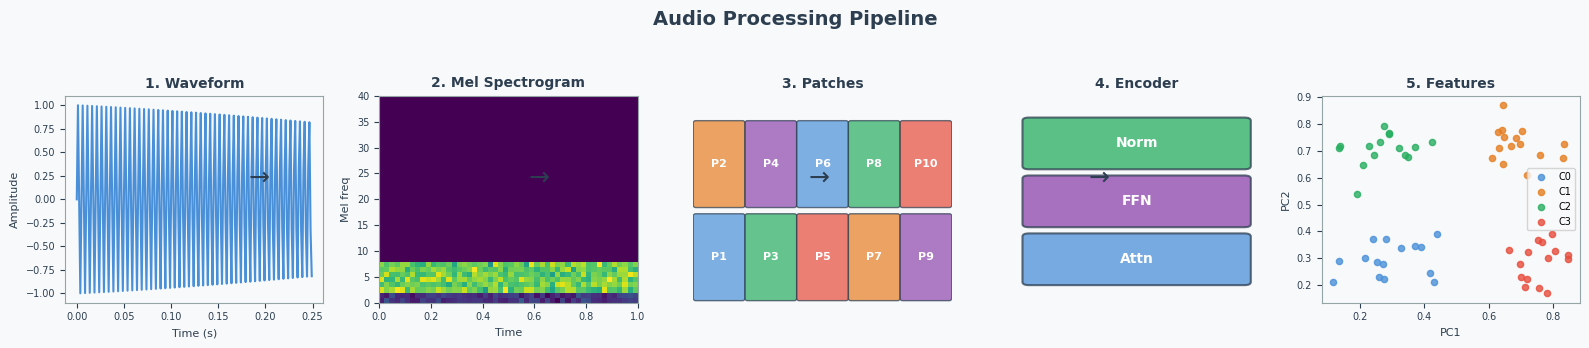

In [2]:
def draw_audio_pipeline():
    """Waveform → Mel Spectrogram → Patches → Encoder → Features"""
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), facecolor=PAL['bg'])
    fig.suptitle('Audio Processing Pipeline', color=PAL['dark'], fontsize=14, fontweight='bold')

    # --- Panel 1: Waveform ---
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    t = np.linspace(0, 1, 800)
    wave = np.sin(2 * np.pi * 200 * t) * np.exp(-t * 0.5)
    ax.plot(t[:200], wave[:200], color=PAL['blue'], lw=1.5)
    ax.set_title('1. Waveform', color=PAL['dark'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)', color=PAL['dark'], fontsize=8)
    ax.set_ylabel('Amplitude', color=PAL['dark'], fontsize=8)
    ax.tick_params(colors=PAL['dark'], labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])

    # --- Panel 2: Mel Spectrogram ---
    ax = axes[1]
    ax.set_facecolor(PAL['bg'])
    # Fake a nice-looking mel spectrogram
    np.random.seed(0)
    mel = np.zeros((40, 50))
    # Low-frequency energy band
    mel[2:8, :] = 2.5 + np.random.randn(6, 50) * 0.3
    mel[0:2, :] = 0.5 + np.random.randn(2, 50) * 0.2
    mel = np.maximum(mel, 0)
    im = ax.imshow(mel, aspect='auto', origin='lower', cmap='viridis',
                   extent=[0, 1, 0, 40])
    ax.set_title('2. Mel Spectrogram', color=PAL['dark'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Time', color=PAL['dark'], fontsize=8)
    ax.set_ylabel('Mel freq', color=PAL['dark'], fontsize=8)
    ax.tick_params(colors=PAL['dark'], labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])

    # --- Panel 3: Patches ---
    ax = axes[2]
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    patch_colors = [PAL['blue'], PAL['orange'], PAL['green'], PAL['purple'],
                    PAL['red'], PAL['blue'], PAL['orange'], PAL['green'],
                    PAL['purple'], PAL['red']]
    for i in range(5):
        for j in range(2):
            idx = i * 2 + j
            rect = mpatches.FancyBboxPatch((i*2 + 0.1, j*4.5 + 0.2), 1.8, 4,
                boxstyle='round,pad=0.1', linewidth=1,
                edgecolor=PAL['dark'], facecolor=patch_colors[idx], alpha=0.7)
            ax.add_patch(rect)
            ax.text(i*2+1, j*4.5+2.2, f'P{idx+1}', ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold')
    ax.set_title('3. Patches', color=PAL['dark'], fontsize=10, fontweight='bold')
    ax.axis('off')

    # --- Panel 4: Transformer Encoder ---
    ax = axes[3]
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 6); ax.set_ylim(0, 10); ax.axis('off')
    ax.set_title('4. Encoder', color=PAL['dark'], fontsize=10, fontweight='bold')
    block_colors = [PAL['blue'], PAL['purple'], PAL['green']]
    labels = ['Attn', 'FFN', 'Norm']
    for i, (col, lbl) in enumerate(zip(block_colors, labels)):
        rect = mpatches.FancyBboxPatch((0.5, 1 + i*2.8), 5, 2.2,
            boxstyle='round,pad=0.15', linewidth=1.5,
            edgecolor=PAL['dark'], facecolor=col, alpha=0.75)
        ax.add_patch(rect)
        ax.text(3, 2.1 + i*2.8, lbl, ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

    # --- Panel 5: Feature Output ---
    ax = axes[4]
    ax.set_facecolor(PAL['bg'])
    np.random.seed(1)
    colors_pts = [PAL['blue'], PAL['orange'], PAL['green'], PAL['red']]
    for cls in range(4):
        cx, cy = [0.3, 0.7, 0.25, 0.75][cls], [0.3, 0.7, 0.7, 0.3][cls]
        xs = cx + np.random.randn(15) * 0.08
        ys = cy + np.random.randn(15) * 0.08
        ax.scatter(xs, ys, color=colors_pts[cls], s=20, alpha=0.8, label=f'C{cls}')
    ax.set_title('5. Features', color=PAL['dark'], fontsize=10, fontweight='bold')
    ax.set_xlabel('PC1', color=PAL['dark'], fontsize=8)
    ax.set_ylabel('PC2', color=PAL['dark'], fontsize=8)
    ax.tick_params(colors=PAL['dark'], labelsize=7)
    ax.legend(fontsize=7, facecolor=PAL['bg'])
    for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])

    # Arrows between panels
    for i in range(4):
        fig.text(0.165 + i * 0.175, 0.5, '→',
                 ha='center', va='center', fontsize=18, color=PAL['dark'])

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

draw_audio_pipeline()

---
## Problem 0 — Generating Synthetic Audio Data

We generate four classes of synthetic audio using NumPy only:

| Class | Signal | Key feature |
|-------|--------|-------------|
| 0 | Low-freq sine (200 Hz) | Energy at low mel bins |
| 1 | High-freq sine (1000 Hz) | Energy at high mel bins |
| 2 | Two-tone chord (200 + 600 Hz) | Energy at two mel bands |
| 3 | Noise burst | Broadband energy with decay |

Each sample is 1 second at 8,000 Hz = **8,000 samples** — enough to demonstrate
all the key concepts without heavy computation.

In [3]:
class SyntheticAudioDataset(Dataset):
    """
    4 classes of synthetic audio signals (no torchaudio / librosa).
    0: Low frequency sine wave (200 Hz)
    1: High frequency sine wave (1000 Hz)
    2: Two-tone chord (200 Hz + 600 Hz)
    3: Noise burst (random noise with amplitude envelope)

    Each sample: 1 second at 8000 Hz sample rate = 8000 samples.
    """
    def __init__(self, n_per_class=100, sr=8000, duration=1.0, seed=42):
        self.sr       = sr
        self.duration = duration
        self.n_per_class = n_per_class
        rng = np.random.RandomState(seed)
        self._rng = rng

        self.waveforms = []
        self.labels    = []
        for label in range(4):
            for _ in range(n_per_class):
                wave = self._make_sample(label)
                self.waveforms.append(wave)
                self.labels.append(label)

    def _make_sample(self, label):
        t = np.linspace(0, self.duration, int(self.sr * self.duration))
        if label == 0:
            wave = np.sin(2 * np.pi * 200 * t)
        elif label == 1:
            wave = np.sin(2 * np.pi * 1000 * t)
        elif label == 2:
            wave = 0.5 * np.sin(2 * np.pi * 200 * t) + 0.5 * np.sin(2 * np.pi * 600 * t)
        else:
            wave = self._rng.randn(len(t)) * np.exp(-t * 2)
        # Add small noise for variation
        wave = wave + self._rng.randn(len(t)) * 0.05
        return wave.astype(np.float32)

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        return torch.from_numpy(self.waveforms[idx]), self.labels[idx]

# Build dataset
audio_ds = SyntheticAudioDataset(n_per_class=100, sr=8000, seed=42)
print(f"Dataset size: {len(audio_ds)}")
wave0, lbl0 = audio_ds[0]
print(f"Waveform shape: {wave0.shape},  dtype: {wave0.dtype},  label: {lbl0}")
print(f"Sample rate: 8000 Hz  |  Duration: 1.0 s  |  Samples per clip: {wave0.shape[0]}")

Dataset size: 400
Waveform shape: torch.Size([8000]),  dtype: torch.float32,  label: 0
Sample rate: 8000 Hz  |  Duration: 1.0 s  |  Samples per clip: 8000


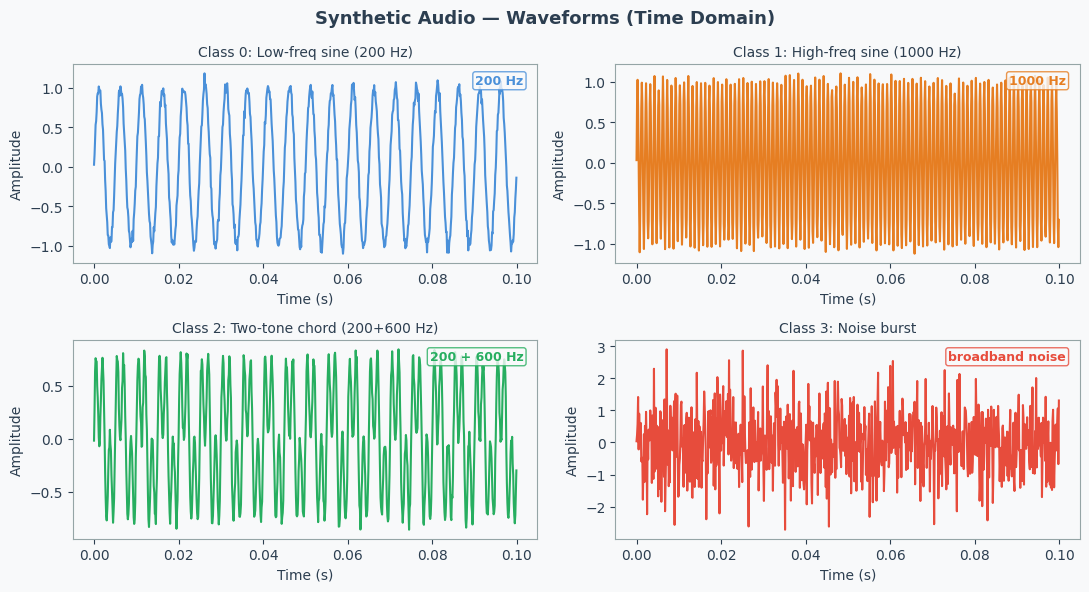

In [4]:
def show_waveforms(dataset, sr=8000):
    """2x2 grid of one waveform per class (time domain)."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 6), facecolor=PAL['bg'])
    fig.suptitle('Synthetic Audio — Waveforms (Time Domain)', color=PAL['dark'],
                 fontsize=13, fontweight='bold')
    colors = [PAL['blue'], PAL['orange'], PAL['green'], PAL['red']]
    annots = ['200 Hz', '1000 Hz', '200 + 600 Hz', 'broadband noise']

    # Pick first sample of each class
    class_indices = []
    for cls in range(4):
        for i in range(len(dataset)):
            if dataset.labels[i] == cls:
                class_indices.append(i)
                break

    for idx, (cls, ax) in enumerate(zip(class_indices, axes.flat)):
        wave, lbl = dataset[cls]
        wave = wave.numpy()
        t = np.linspace(0, 1, len(wave))
        ax.set_facecolor(PAL['bg'])
        ax.plot(t[:800], wave[:800], color=colors[idx], lw=1.5)
        ax.set_title(f'Class {lbl}: {CLASS_NAMES[lbl]}', color=PAL['dark'], fontsize=10)
        ax.set_xlabel('Time (s)', color=PAL['dark'])
        ax.set_ylabel('Amplitude', color=PAL['dark'])
        ax.tick_params(colors=PAL['dark'])
        ax.text(0.97, 0.95, annots[idx], transform=ax.transAxes, ha='right', va='top',
                color=colors[idx], fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=PAL['bg'],
                          edgecolor=colors[idx], alpha=0.8))
        for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])

    plt.tight_layout()
    plt.show()

show_waveforms(audio_ds)

## Problem 2 — How do we compute a mel spectrogram from scratch?

A raw waveform is a sequence of amplitude samples — 8 000 per second at the sample rate used here. A Transformer cannot process this directly: the sequence would be too long, and individual samples carry no semantic structure.

**Why mel — before we dive into the maths:**  
The human ear does not perceive frequencies linearly. A 50 Hz difference at 100 Hz (low bass) is very audible — you can hear the pitch change clearly. The same 50 Hz difference at 5 000 Hz is almost imperceptible. This means a linear-frequency spectrogram wastes most of its resolution on high-frequency detail that a listener (and a model) cannot distinguish. The mel scale warps the frequency axis to match human perception, so equal spacing on the mel axis corresponds to equal *perceived* pitch differences. The practical payoff for the architecture:

- **Fewer bins** are needed: 64 mel bins capture all perceptually meaningful detail vs. 129 raw FFT bins for the same audio.
- **The Transformer attends to the right things**: each mel bin corresponds to a perceptually distinct region; raw FFT bins at high frequency do not.
- **The result is a 2D image** (mel bins × time frames) that a Transformer processes *exactly like an image* — this is the direct audio analogue of the patch grid in ViT (Ch01).

**Four steps from waveform to mel spectrogram:**

1. **STFT** — divide the waveform into short overlapping windows; take FFT of each window.  
   Each window → one column of the spectrogram.
2. **Power spectrum** — $|\text{STFT}|^2$, discard phase information.
3. **Mel filterbank** — warp the frequency axis using the mel scale so that equal spacing  
   on the mel axis corresponds to equal perceived pitch differences:  
   $\text{mel} = 2595 \cdot \log_{10}(1 + f/700)$
4. **Log scale** — $\log(S + \epsilon)$, mimicking the ear's logarithmic sensitivity to loudness.

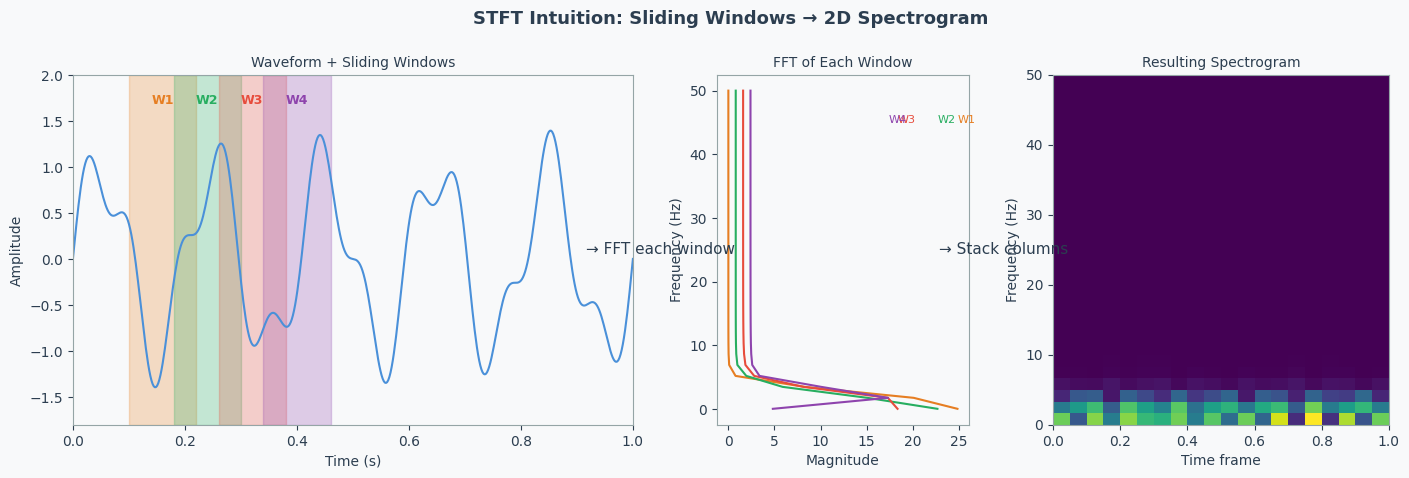

In [5]:
def draw_stft_intuition():
    """
    Diagram: long waveform split into overlapping windows,
    each window → FFT → one column of spectrogram.
    """
    fig = plt.figure(figsize=(14, 5), facecolor=PAL['bg'])
    fig.suptitle('STFT Intuition: Sliding Windows → 2D Spectrogram',
                 color=PAL['dark'], fontsize=13, fontweight='bold')

    # --- Left: waveform with windows ---
    ax1 = fig.add_axes([0.03, 0.15, 0.40, 0.70])
    ax1.set_facecolor(PAL['bg'])
    np.random.seed(7)
    t = np.linspace(0, 1, 500)
    wave = np.sin(2 * np.pi * 5 * t) + 0.4 * np.sin(2 * np.pi * 12 * t)
    ax1.plot(t, wave, color=PAL['blue'], lw=1.5, zorder=2)

    window_size = 0.12
    hop = 0.08
    win_colors = [PAL['orange'], PAL['green'], PAL['red'], PAL['purple']]
    starts = [0.10, 0.18, 0.26, 0.34]
    for i, (s, c) in enumerate(zip(starts, win_colors)):
        ax1.axvspan(s, s + window_size, alpha=0.25, color=c, zorder=1)
        ax1.text(s + window_size/2, 1.65, f'W{i+1}', ha='center', va='bottom',
                 color=c, fontsize=9, fontweight='bold')

    ax1.set_xlim(0, 1); ax1.set_ylim(-1.8, 2.0)
    ax1.set_xlabel('Time (s)', color=PAL['dark'])
    ax1.set_ylabel('Amplitude', color=PAL['dark'])
    ax1.set_title('Waveform + Sliding Windows', color=PAL['dark'], fontsize=10)
    ax1.tick_params(colors=PAL['dark'])
    for sp in ax1.spines.values(): sp.set_edgecolor(PAL['grey'])

    # Arrow
    fig.text(0.45, 0.5, u'→ FFT each window', ha='center', va='center',
             fontsize=11, color=PAL['dark'])

    # --- Middle: FFT of each window ---
    ax2 = fig.add_axes([0.49, 0.15, 0.18, 0.70])
    ax2.set_facecolor(PAL['bg'])
    freqs = np.linspace(0, 50, 30)
    for i, (s, c) in enumerate(zip(starts, win_colors)):
        t_win = np.linspace(s, s + window_size, 64)
        win_wave = np.sin(2 * np.pi * 5 * t_win) + 0.4 * np.sin(2 * np.pi * 12 * t_win)
        fft_mag = np.abs(np.fft.rfft(win_wave * np.hanning(len(t_win)), n=64))[:30]
        offset = i * 0.8
        ax2.plot(fft_mag + offset, freqs, color=c, lw=1.5)
        ax2.text(fft_mag.max() + offset + 0.05, 45, f'W{i+1}', color=c, fontsize=8)
    ax2.set_xlabel('Magnitude', color=PAL['dark'])
    ax2.set_ylabel('Frequency (Hz)', color=PAL['dark'])
    ax2.set_title('FFT of Each Window', color=PAL['dark'], fontsize=10)
    ax2.tick_params(colors=PAL['dark'])
    for sp in ax2.spines.values(): sp.set_edgecolor(PAL['grey'])

    # Arrow
    fig.text(0.695, 0.5, u'→ Stack columns', ha='center', va='center',
             fontsize=11, color=PAL['dark'])

    # --- Right: resulting spectrogram ---
    ax3 = fig.add_axes([0.73, 0.15, 0.24, 0.70])
    ax3.set_facecolor(PAL['bg'])
    n_win = 20
    n_freq = 30
    spec = np.zeros((n_freq, n_win))
    t_grid = np.linspace(0, 1, n_win)
    for j, tj in enumerate(t_grid):
        t_w = np.linspace(tj, tj + 0.12, 64)
        w = np.sin(2 * np.pi * 5 * t_w) + 0.4 * np.sin(2 * np.pi * 12 * t_w)
        fft_m = np.abs(np.fft.rfft(w * np.hanning(len(t_w)), n=64))[:n_freq]
        spec[:, j] = fft_m

    ax3.imshow(spec, aspect='auto', origin='lower', cmap='viridis',
               extent=[0, 1, 0, 50])
    ax3.set_xlabel('Time frame', color=PAL['dark'])
    ax3.set_ylabel('Frequency (Hz)', color=PAL['dark'])
    ax3.set_title('Resulting Spectrogram', color=PAL['dark'], fontsize=10)
    ax3.tick_params(colors=PAL['dark'])
    for sp in ax3.spines.values(): sp.set_edgecolor(PAL['grey'])

    plt.show()

draw_stft_intuition()

### Mel Spectrogram Implementation (NumPy + SciPy only)

In [6]:
def compute_mel_spectrogram(waveform, sr=8000, n_fft=256, hop_length=64,
                             n_mels=40, fmin=20, fmax=None):
    """
    Compute log mel spectrogram from raw waveform.
    No torchaudio or librosa — only numpy and scipy.signal.

    waveform : numpy array of shape (T,)
    Returns  : (n_mels, time_frames) numpy array
    """
    if fmax is None:
        fmax = sr // 2

    # ── 1. STFT: divide into frames and apply FFT ────────────────────────────
    freqs, times, Zxx = scipy_signal.stft(
        waveform, fs=sr, nperseg=n_fft, noverlap=n_fft - hop_length,
        window='hann'
    )
    power = np.abs(Zxx) ** 2  # (n_fft//2+1, T)

    # ── 2. Mel filterbank ────────────────────────────────────────────────────
    def hz_to_mel(hz):
        return 2595.0 * np.log10(1.0 + hz / 700.0)

    def mel_to_hz(mel):
        return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points  = mel_to_hz(mel_points)

    # Convert Hz to FFT bin indices
    bin_indices = np.floor((n_fft + 1) * hz_points / sr).astype(int)
    bin_indices = np.clip(bin_indices, 0, n_fft // 2)

    n_bins = n_fft // 2 + 1
    filterbank = np.zeros((n_mels, n_bins), dtype=np.float32)
    for m in range(1, n_mels + 1):
        lo, ctr, hi = bin_indices[m-1], bin_indices[m], bin_indices[m+1]
        if ctr > lo:
            for k in range(lo, min(ctr, n_bins)):
                filterbank[m-1, k] = (k - lo) / (ctr - lo)
        if hi > ctr:
            for k in range(ctr, min(hi, n_bins)):
                filterbank[m-1, k] = (hi - k) / (hi - ctr)

    # ── 3. Apply filterbank and take log ─────────────────────────────────────
    mel_power = filterbank @ power        # (n_mels, T)
    log_mel   = np.log(mel_power + 1e-8)  # log scale

    return log_mel.astype(np.float32)


# Quick test
wave_test, _ = audio_ds[0]
mel = compute_mel_spectrogram(wave_test.numpy(), sr=8000)
print(f"Waveform shape : {wave_test.shape}")
print(f"Mel spec shape : {mel.shape}  (n_mels=40 x time_frames)")

Waveform shape : torch.Size([8000])
Mel spec shape : (40, 126)  (n_mels=40 x time_frames)


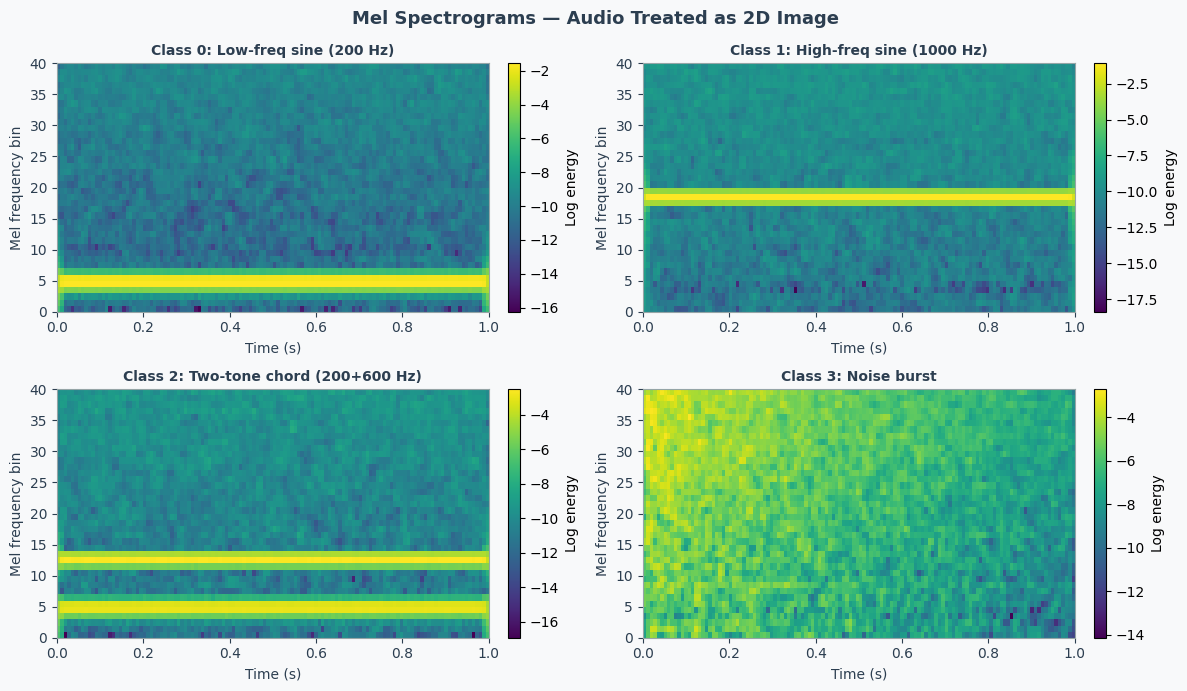

Key insight: each class has a DISTINCT visual pattern in the mel spectrogram!
  Class 0 (200 Hz): bright stripe at low mel bins
  Class 1 (1000 Hz): bright stripe at high mel bins
  Class 2 (two-tone): two distinct bright stripes
  Class 3 (noise): broad energy across all bins, fading over time


In [7]:
def show_mel_spectrograms(dataset, sr=8000):
    """
    2x2 grid of mel spectrograms — one per class.
    This is the KEY visualisation: audio → image.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), facecolor=PAL['bg'])
    fig.suptitle('Mel Spectrograms — Audio Treated as 2D Image',
                 color=PAL['dark'], fontsize=13, fontweight='bold')

    # Pick first sample of each class
    class_indices = {}
    for i in range(len(dataset)):
        lbl = dataset.labels[i]
        if lbl not in class_indices:
            class_indices[lbl] = i
        if len(class_indices) == 4:
            break

    for cls, ax in zip(range(4), axes.flat):
        wave, lbl = dataset[class_indices[cls]]
        mel = compute_mel_spectrogram(wave.numpy(), sr=sr)
        ax.set_facecolor(PAL['bg'])
        im = ax.imshow(mel, aspect='auto', origin='lower', cmap='viridis',
                       extent=[0, 1.0, 0, 40])
        ax.set_title(f'Class {cls}: {CLASS_NAMES[cls]}', color=PAL['dark'],
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)', color=PAL['dark'])
        ax.set_ylabel('Mel frequency bin', color=PAL['dark'])
        ax.tick_params(colors=PAL['dark'])
        for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                     label='Log energy')

    plt.tight_layout()
    plt.show()
    print("Key insight: each class has a DISTINCT visual pattern in the mel spectrogram!")
    print("  Class 0 (200 Hz): bright stripe at low mel bins")
    print("  Class 1 (1000 Hz): bright stripe at high mel bins")
    print("  Class 2 (two-tone): two distinct bright stripes")
    print("  Class 3 (noise): broad energy across all bins, fading over time")

show_mel_spectrograms(audio_ds)

### Building a Mel Spectrogram Dataset

Now we create a `Dataset` that returns mel spectrograms instead of raw waveforms.
These will be the inputs to our Whisper-style encoder.

In [8]:
class MelSpectrogramDataset(Dataset):
    """Wraps SyntheticAudioDataset, returning mel spectrograms as tensors."""
    def __init__(self, audio_dataset, sr=8000, n_fft=256, hop_length=64, n_mels=40):
        self.sr         = sr
        self.n_mels     = n_mels
        self.n_fft      = n_fft
        self.hop_length = hop_length

        self.mels   = []
        self.labels = []
        for i in range(len(audio_dataset)):
            wave, lbl = audio_dataset[i]
            mel = compute_mel_spectrogram(
                wave.numpy(), sr=sr, n_fft=n_fft,
                hop_length=hop_length, n_mels=n_mels
            )
            self.mels.append(mel)   # (n_mels, T)
            self.labels.append(lbl)

        # Normalise globally
        all_mels = np.stack(self.mels)   # (N, n_mels, T)
        self.mean = all_mels.mean()
        self.std  = all_mels.std() + 1e-8
        self.n_frames = self.mels[0].shape[1]

    def __len__(self):
        return len(self.mels)

    def __getitem__(self, idx):
        mel = (self.mels[idx] - self.mean) / self.std  # normalise
        return torch.from_numpy(mel).unsqueeze(0), self.labels[idx]  # (1, n_mels, T)


mel_ds = MelSpectrogramDataset(audio_ds)
x, y = mel_ds[0]
print(f"Mel spec tensor shape: {x.shape}  (1 channel x {x.shape[1]} mels x {x.shape[2]} frames)")
print(f"Label: {y}  ({CLASS_NAMES[y]})")
print(f"n_frames per sample: {mel_ds.n_frames}")

Mel spec tensor shape: torch.Size([1, 40, 126])  (1 channel x 40 mels x 126 frames)
Label: 0  (Low-freq sine (200 Hz))
n_frames per sample: 126


---
## Problem 3 — Whisper architecture: how does it understand speech?

Whisper uses an **encoder-decoder Transformer**:

```
Audio → Mel Spec → Conv1D Frontend → Bidirectional Encoder → Cross-Attention Decoder → Transcript
```

**Encoder** (bidirectional — sees the full audio):
1. Two `Conv1d` layers reduce the time dimension (stride=2 each, giving 4× compression). Unlike patch embedding (which is a *linear projection* of fixed-size windows), these Conv1d layers **learn frequency-selective filters** — each kernel learns to detect specific temporal patterns in the mel spectrogram, analogous to edge detectors in a CNN vision backbone. The result is a sequence of learned feature vectors, one per compressed time frame.
2. Sinusoidal positional encoding
3. Stack of Transformer blocks with **full (non-causal) attention**

**Decoder** (causal — generates tokens left to right):
1. Learned token embeddings + positional encoding
2. Causal self-attention (masked)
3. **Cross-attention**: decoder queries attend to encoder outputs
4. Autoregressive generation

> **Connection to Chapter 3 (VLM):** the audio encoder plays exactly the role that the
> ViT encoder played — it maps raw input into a sequence of contextualised embeddings
> that the language model can attend to via cross-attention.

In [9]:
class AudioPatchEmbedding(nn.Module):
    """
    Treat mel spectrogram as a 2D image and apply Conv2d patch embedding.
    Input : (B, 1, n_mels, T)  — 1-channel mel spectrogram
    Output: (B, N, D)          — sequence of patch embeddings
    """
    def __init__(self, n_mels, n_frames, patch_height, patch_width, embed_dim):
        super().__init__()
        assert n_mels   % patch_height == 0, f"n_mels={n_mels} must be divisible by patch_height={patch_height}"
        assert n_frames % patch_width  == 0, f"n_frames={n_frames} must be divisible by patch_width={patch_width}"
        self.n_patches_h = n_mels   // patch_height
        self.n_patches_w = n_frames // patch_width
        self.n_patches   = self.n_patches_h * self.n_patches_w
        self.proj = nn.Conv2d(1, embed_dim,
                              kernel_size=(patch_height, patch_width),
                              stride=(patch_height, patch_width))

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        x = self.proj(x)           # (B, D, H//ph, W//pw)
        B, D, H, W = x.shape
        x = x.flatten(2)           # (B, D, N)
        x = x.transpose(1, 2)      # (B, N, D)
        return x


# Shape check
_pe = AudioPatchEmbedding(n_mels=40, n_frames=120, patch_height=5, patch_width=10, embed_dim=64)
_inp = torch.randn(2, 1, 40, 120)
_out = _pe(_inp)
print(f"Input shape  : {_inp.shape}")
print(f"Output shape : {_out.shape}  (B, N_patches, embed_dim)")
print(f"N patches    : {_pe.n_patches}  ({_pe.n_patches_h} freq × {_pe.n_patches_w} time)")

Input shape  : torch.Size([2, 1, 40, 120])
Output shape : torch.Size([2, 96, 64])  (B, N_patches, embed_dim)
N patches    : 96  (8 freq × 12 time)


In [10]:
class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention. causal=True applies a causal mask."""
    def __init__(self, embed_dim, n_heads, causal=False):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = embed_dim // n_heads
        self.causal   = causal
        self.qkv  = nn.Linear(embed_dim, 3 * embed_dim, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        H, hd = self.n_heads, self.head_dim
        qkv = self.qkv(x).reshape(B, T, 3, H, hd).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scale = hd ** -0.5
        attn  = (q @ k.transpose(-2, -1)) * scale          # (B, H, T, T)
        if self.causal:
            causal_mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
            attn = attn.masked_fill(~causal_mask, float('-inf'))
        if mask is not None:
            attn = attn + mask
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1, 2).reshape(B, T, D)
        return self.proj(out)


class CrossAttention(nn.Module):
    """Cross-attention: decoder queries attend to encoder key-value pairs."""
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = embed_dim // n_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out    = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, enc_out):
        B, T_dec, D = x.shape
        _,  T_enc, _ = enc_out.shape
        H, hd = self.n_heads, self.head_dim
        q = self.q_proj(x      ).reshape(B, T_dec, H, hd).transpose(1, 2)
        k = self.k_proj(enc_out).reshape(B, T_enc, H, hd).transpose(1, 2)
        v = self.v_proj(enc_out).reshape(B, T_enc, H, hd).transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) * (hd ** -0.5)
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1, 2).reshape(B, T_dec, D)
        return self.out(out)


class TransformerEncoderBlock(nn.Module):
    """Bidirectional (non-causal) Transformer block for audio encoding."""
    def __init__(self, embed_dim, n_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, n_heads, causal=False)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Linear(embed_dim * mlp_ratio, embed_dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class TransformerDecoderBlock(nn.Module):
    """Causal Transformer decoder block with cross-attention."""
    def __init__(self, embed_dim, n_heads, mlp_ratio=4):
        super().__init__()
        self.norm1      = nn.LayerNorm(embed_dim)
        self.self_attn  = MultiHeadSelfAttention(embed_dim, n_heads, causal=True)
        self.norm2      = nn.LayerNorm(embed_dim)
        self.cross_attn = CrossAttention(embed_dim, n_heads)
        self.norm3      = nn.LayerNorm(embed_dim)
        self.mlp        = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Linear(embed_dim * mlp_ratio, embed_dim)
        )

    def forward(self, x, enc_out):
        x = x + self.self_attn(self.norm1(x))
        x = x + self.cross_attn(self.norm2(x), enc_out)
        x = x + self.mlp(self.norm3(x))
        return x

In [11]:
def sinusoidal_pos_enc(seq_len, embed_dim, device='cpu'):
    """Standard sinusoidal positional encoding."""
    pos  = torch.arange(seq_len, device=device).float().unsqueeze(1)
    i    = torch.arange(embed_dim, device=device).float().unsqueeze(0)
    freq = torch.pow(10000.0, -i / embed_dim)
    enc  = torch.where(i % 2 == 0, torch.sin(pos * freq), torch.cos(pos * freq))
    return enc.unsqueeze(0)   # (1, seq_len, embed_dim)


class AudioEncoder(nn.Module):
    """
    Whisper-style audio encoder.

    Architecture:
      1. Two Conv1D layers operating along the time axis (temporal downsampling)
      2. Linear projection to embed_dim
      3. Sinusoidal positional encoding
      4. Stack of bidirectional Transformer encoder blocks

    Input : (B, 1, n_mels, T)
    Output: (B, T', embed_dim)  — contextualised audio features
    """
    def __init__(self, n_mels=40, n_frames=120, embed_dim=64, depth=3,
                 n_heads=4, conv_channels=32):
        super().__init__()
        # Conv1D frontend: operate along the time axis
        # Treat mel spectrogram as (B, n_mels, T), apply 1D convs over T
        self.conv1 = nn.Conv1d(n_mels, conv_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(conv_channels, embed_dim,
                               kernel_size=3, stride=2, padding=1)
        self.n_out_frames = n_frames // 2  # stride-2 halves time
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, n_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        B, C, n_mel, T = x.shape
        x = x.squeeze(1)                       # (B, n_mels, T)
        x = F.gelu(self.conv1(x))              # (B, conv_ch, T)
        x = F.gelu(self.conv2(x))              # (B, embed_dim, T//2)
        x = x.transpose(1, 2)                  # (B, T//2, embed_dim)
        # Positional encoding
        pos = sinusoidal_pos_enc(x.shape[1], x.shape[2], device=x.device)
        x = x + pos
        x = self.proj(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                    # (B, T//2, embed_dim)


# Shape check
encoder = AudioEncoder(n_mels=40, n_frames=mel_ds.n_frames, embed_dim=64, depth=3, n_heads=4)
_inp = torch.randn(2, 1, 40, mel_ds.n_frames)
_enc = encoder(_inp)
print(f"Encoder input  shape: {_inp.shape}")
print(f"Encoder output shape: {_enc.shape}  (B, T', D)")
n_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters : {n_params:,}  (~{n_params/1e3:.1f}k)")

Encoder input  shape: torch.Size([2, 1, 40, 126])
Encoder output shape: torch.Size([2, 63, 64])  (B, T', D)
Encoder parameters : 163,552  (~163.6k)


In [12]:
class WhisperStyleModel(nn.Module):
    """
    Whisper-style encoder-decoder for audio classification.

    For classification we:
      1. Run the audio through the encoder
      2. Average-pool the encoder outputs
      3. Project to num_classes

    This is the 'encoder-only' training mode (like BERT for classification).
    The decoder with cross-attention is shown separately for illustration.
    """
    def __init__(self, n_mels=40, n_frames=120, embed_dim=64, depth=3,
                 n_heads=4, num_classes=4):
        super().__init__()
        self.encoder    = AudioEncoder(n_mels=n_mels, n_frames=n_frames,
                                       embed_dim=embed_dim, depth=depth,
                                       n_heads=n_heads)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        enc = self.encoder(x)          # (B, T', D)
        pooled = enc.mean(dim=1)       # (B, D)
        return self.classifier(pooled) # (B, num_classes)

    def encode(self, x):
        """Return raw encoder features (B, T', D)."""
        return self.encoder(x)


# Shape check
model = WhisperStyleModel(
    n_mels=40, n_frames=mel_ds.n_frames,
    embed_dim=64, depth=3, n_heads=4, num_classes=4
).to(DEVICE)
_inp = torch.randn(4, 1, 40, mel_ds.n_frames, device=DEVICE)
_out = model(_inp)
print(f"Model output shape: {_out.shape}  (B, num_classes)")
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters  : {n_params:,}  (~{n_params/1e3:.1f}k)")

Model output shape: torch.Size([4, 4])  (B, num_classes)
Total parameters  : 167,972  (~168.0k)


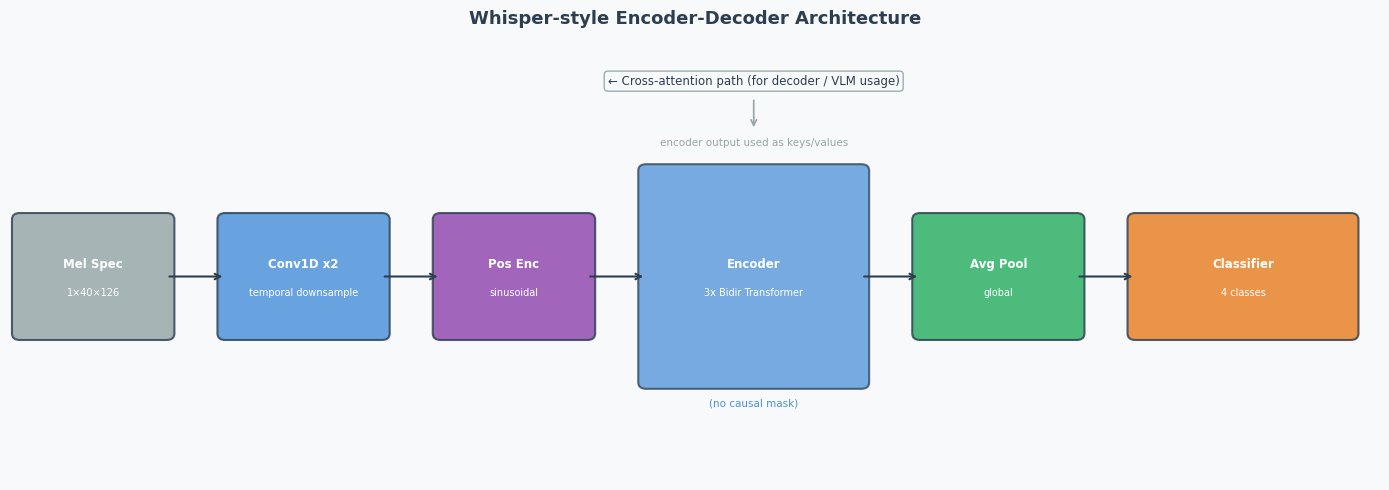

In [13]:
def draw_whisper_architecture(n_frames=120, embed_dim=64):
    fig, ax = plt.subplots(figsize=(14, 5), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 14); ax.set_ylim(0, 5.5)
    ax.axis('off')
    ax.set_title('Whisper-style Encoder-Decoder Architecture',
                 color=PAL['dark'], fontsize=13, fontweight='bold')

    def box(x, y, w, h, color, label, sub='', alpha=0.82):
        r = mpatches.FancyBboxPatch((x, y), w, h,
            boxstyle='round,pad=0.08', linewidth=1.5,
            edgecolor=PAL['dark'], facecolor=color, alpha=alpha)
        ax.add_patch(r)
        ax.text(x + w/2, y + h/2 + (0.15 if sub else 0), label,
                ha='center', va='center', color='white',
                fontsize=8.5, fontweight='bold')
        if sub:
            ax.text(x + w/2, y + h/2 - 0.2, sub,
                    ha='center', va='center', color='white', fontsize=7)

    def arr(x1, y1, x2, y2, color=None):
        color = color or PAL['dark']
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    # Input
    box(0.1, 1.8, 1.5, 1.4, PAL['grey'], 'Mel Spec', f'1×40×{n_frames}')
    arr(1.6, 2.5, 2.2, 2.5)

    # Conv frontend
    box(2.2, 1.8, 1.6, 1.4, PAL['blue'], 'Conv1D x2', 'temporal downsample')
    arr(3.8, 2.5, 4.4, 2.5)

    # Pos enc
    box(4.4, 1.8, 1.5, 1.4, PAL['purple'], 'Pos Enc', 'sinusoidal')
    arr(5.9, 2.5, 6.5, 2.5)

    # Encoder blocks
    box(6.5, 1.2, 2.2, 2.6, PAL['blue'], 'Encoder', '3x Bidir Transformer', alpha=0.75)
    ax.text(7.6, 0.9, '(no causal mask)', ha='center', color=PAL['blue'], fontsize=7.5)
    arr(8.7, 2.5, 9.3, 2.5)

    # Avg pool + classifier
    box(9.3, 1.8, 1.6, 1.4, PAL['green'], 'Avg Pool', 'global')
    arr(10.9, 2.5, 11.5, 2.5)

    box(11.5, 1.8, 2.2, 1.4, PAL['orange'], 'Classifier', '4 classes')

    # Cross-attention label (decoder path)
    ax.text(7.6, 4.9, '← Cross-attention path (for decoder / VLM usage)',
            ha='center', va='center', color=PAL['dark'], fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PAL['bg'],
                      edgecolor=PAL['grey'], alpha=0.9))
    ax.annotate('', xy=(7.6, 4.3), xytext=(7.6, 4.7),
                arrowprops=dict(arrowstyle='->', color=PAL['grey'], lw=1.2))
    ax.text(7.6, 4.1, 'encoder output used as keys/values', ha='center',
            color=PAL['grey'], fontsize=7.5)

    plt.tight_layout()
    plt.show()

draw_whisper_architecture(n_frames=mel_ds.n_frames)

---
## Training the Whisper-style Classifier

We train with **cross-entropy loss** using **teacher forcing** on class labels.
The training objective mirrors Whisper's: predict the correct class token
given the audio encoder's output.

In [14]:
def train_audio_model(model, dataset, n_epochs=15, batch_size=64, lr=3e-4):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    losses = []
    accs   = []
    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        correct    = 0
        total      = 0
        for x, y in loader:
            x, y = x.to(DEVICE), torch.tensor(y, dtype=torch.long, device=DEVICE)
            logits = model(x)
            loss   = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item() * x.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += x.size(0)
        scheduler.step()
        losses.append(epoch_loss / total)
        accs.append(correct / total)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs}  "
                  f"loss={losses[-1]:.4f}  acc={accs[-1]*100:.1f}%")
    return losses, accs

losses, accs = train_audio_model(model, mel_ds, n_epochs=15)
print(f"\nFinal accuracy: {accs[-1]*100:.1f}%  (target: >90%)")

/tmp/ipykernel_30684/975010809.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = x.to(DEVICE), torch.tensor(y, dtype=torch.long, device=DEVICE)


Epoch   5/15  loss=0.3894  acc=100.0%


Epoch  10/15  loss=0.1323  acc=100.0%


Epoch  15/15  loss=0.1083  acc=100.0%

Final accuracy: 100.0%  (target: >90%)


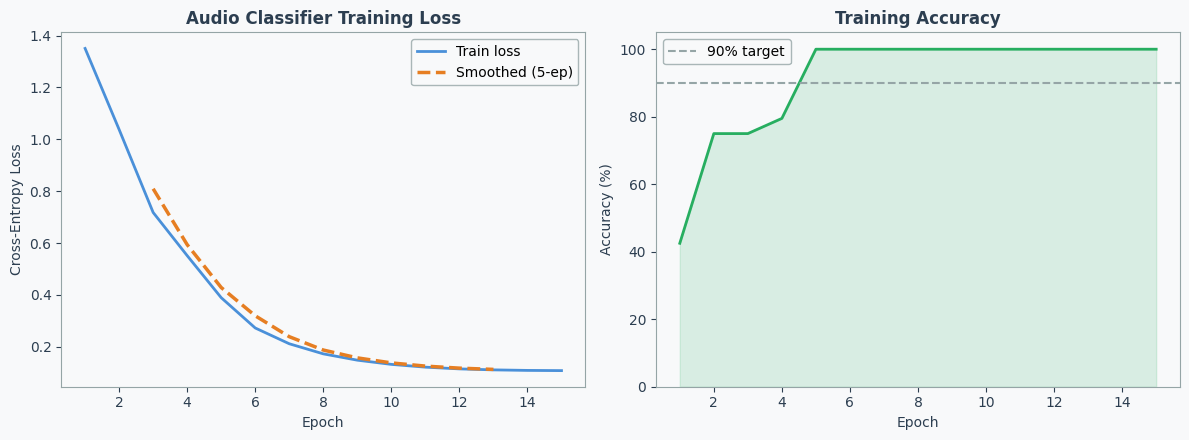

Final loss: 0.1083  |  Final accuracy: 100.0%


In [15]:
def plot_training_loss(losses, accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=PAL['bg'])
    epochs = np.arange(1, len(losses) + 1)

    # Loss
    ax1.set_facecolor(PAL['bg'])
    ax1.plot(epochs, losses, color=PAL['blue'], lw=2, label='Train loss')
    if len(losses) > 5:
        smooth = np.convolve(losses, np.ones(5)/5, mode='valid')
        ax1.plot(np.arange(3, 3+len(smooth)), smooth,
                 color=PAL['orange'], lw=2.5, ls='--', label='Smoothed (5-ep)')
    ax1.set_xlabel('Epoch', color=PAL['dark'])
    ax1.set_ylabel('Cross-Entropy Loss', color=PAL['dark'])
    ax1.set_title('Audio Classifier Training Loss', color=PAL['dark'],
                  fontsize=12, fontweight='bold')
    ax1.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax1.tick_params(colors=PAL['dark'])
    for sp in ax1.spines.values(): sp.set_edgecolor(PAL['grey'])

    # Accuracy
    ax2.set_facecolor(PAL['bg'])
    ax2.plot(epochs, [a*100 for a in accs], color=PAL['green'], lw=2)
    ax2.axhline(90, color=PAL['grey'], ls='--', lw=1.5, label='90% target')
    ax2.fill_between(epochs, [a*100 for a in accs], alpha=0.15, color=PAL['green'])
    ax2.set_xlabel('Epoch', color=PAL['dark'])
    ax2.set_ylabel('Accuracy (%)', color=PAL['dark'])
    ax2.set_title('Training Accuracy', color=PAL['dark'],
                  fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 105)
    ax2.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax2.tick_params(colors=PAL['dark'])
    for sp in ax2.spines.values(): sp.set_edgecolor(PAL['grey'])

    plt.tight_layout()
    plt.show()
    print(f"Final loss: {losses[-1]:.4f}  |  Final accuracy: {accs[-1]*100:.1f}%")

plot_training_loss(losses, accs)

/tmp/ipykernel_30684/1256623105.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_arr = y if isinstance(y, np.ndarray) else np.array(y)


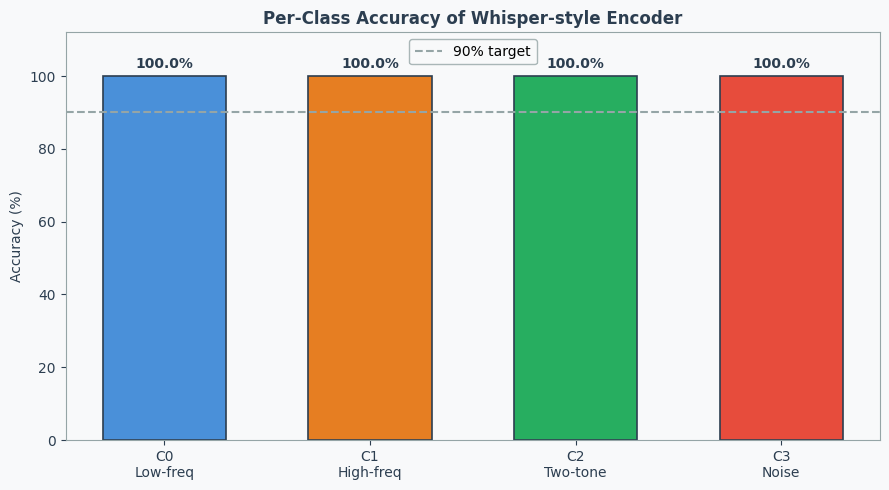

  Class 0 (Low-freq sine (200 Hz)): 100.0%
  Class 1 (High-freq sine (1000 Hz)): 100.0%
  Class 2 (Two-tone chord (200+600 Hz)): 100.0%
  Class 3 (Noise burst): 100.0%


In [16]:
def plot_class_accuracy(model, dataset, device=DEVICE):
    """Bar chart showing per-class accuracy after training."""
    model.eval()
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    correct_per_class = [0] * 4
    total_per_class   = [0] * 4

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y_arr = y if isinstance(y, np.ndarray) else np.array(y)
            logits = model(x)
            preds  = logits.argmax(1).cpu().numpy()
            for pred, true in zip(preds, y_arr):
                total_per_class[int(true)] += 1
                if pred == true:
                    correct_per_class[int(true)] += 1

    accs_per_class = [correct_per_class[c] / max(total_per_class[c], 1) * 100
                      for c in range(4)]

    fig, ax = plt.subplots(figsize=(9, 5), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    colors  = [PAL['blue'], PAL['orange'], PAL['green'], PAL['red']]
    bars    = ax.bar(range(4), accs_per_class, color=colors, width=0.6,
                     edgecolor=PAL['dark'], linewidth=1.2)
    ax.axhline(90, color=PAL['grey'], ls='--', lw=1.5, label='90% target')
    for bar, acc in zip(bars, accs_per_class):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{acc:.1f}%', ha='center', va='bottom',
                color=PAL['dark'], fontsize=10, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'C{i}\n{n.split(" ")[0]}' for i, n in enumerate(CLASS_NAMES)],
                       color=PAL['dark'])
    ax.set_ylabel('Accuracy (%)', color=PAL['dark'])
    ax.set_ylim(0, 112)
    ax.set_title('Per-Class Accuracy of Whisper-style Encoder',
                 color=PAL['dark'], fontsize=12, fontweight='bold')
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax.tick_params(colors=PAL['dark'])
    for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])
    plt.tight_layout()
    plt.show()

    for i, (acc, name) in enumerate(zip(accs_per_class, CLASS_NAMES)):
        print(f"  Class {i} ({name}): {acc:.1f}%")

plot_class_accuracy(model, mel_ds)

---
## Problem 4 — Connecting audio to the rest of the book

In Chapter 3 (VLM Architecture) we saw:
```
Image → ViT encoder → ProjectionMLP → prepend to text tokens → GPT
```

Audio follows exactly the same pattern:
```
Audio → Mel spec → Conv1D → Transformer encoder → ProjectionMLP → prepend to text tokens → LLM
```

This is how **Qwen-Audio**, **GPT-4o**, and other speech-enabled LLMs work internally.
The projection MLP bridges the audio representation space to the language model's embedding space,
and the audio tokens are simply prepended to the text token sequence.

**Key differences from ViT:**
- ViT uses 2D spatial patches; audio encoder uses 1D Conv frontend
- Audio encoder is bidirectional (full attention); image ViT also uses full attention
- Both produce a variable-length sequence of vectors that the LLM can attend to

In [17]:
class AudioProjectionMLP(nn.Module):
    """
    Project audio encoder output to language model embedding space.
    Identical to the ViT → LLM projection MLP from Chapter 3.

    Usage:
        audio_tokens = proj(encoder_output)   # (B, T', lang_dim)
        # Then prepend to text tokens before feeding to LLM
    """
    def __init__(self, audio_dim=64, lang_dim=256, hidden_ratio=2):
        super().__init__()
        hidden = int(lang_dim * hidden_ratio)
        self.net = nn.Sequential(
            nn.Linear(audio_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, lang_dim)
        )

    def forward(self, x):
        return self.net(x)  # (B, T', lang_dim)


# Demonstrate the full audio → language pipeline
audio_proj = AudioProjectionMLP(audio_dim=64, lang_dim=256).to(DEVICE)
sample_mel, _ = mel_ds[0]
sample_mel = sample_mel.unsqueeze(0).to(DEVICE)          # (1, 1, 40, T)

with torch.no_grad():
    enc_out  = model.encode(sample_mel)                   # (1, T', 64)
    lang_tok = audio_proj(enc_out)                        # (1, T', 256)

print("Audio → Language pipeline:")
print(f"  Mel spectrogram : {sample_mel.shape}")
print(f"  Encoder output  : {enc_out.shape}")
print(f"  Language tokens : {lang_tok.shape}")
print()
print("These language tokens can be prepended to text tokens,")
print("exactly like ViT image tokens in Chapter 3 (VLM Architecture).")

Audio → Language pipeline:
  Mel spectrogram : torch.Size([1, 1, 40, 126])
  Encoder output  : torch.Size([1, 63, 64])
  Language tokens : torch.Size([1, 63, 256])

These language tokens can be prepended to text tokens,
exactly like ViT image tokens in Chapter 3 (VLM Architecture).


/tmp/ipykernel_30684/4294701254.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_arr = y if isinstance(y, np.ndarray) else np.array(y)


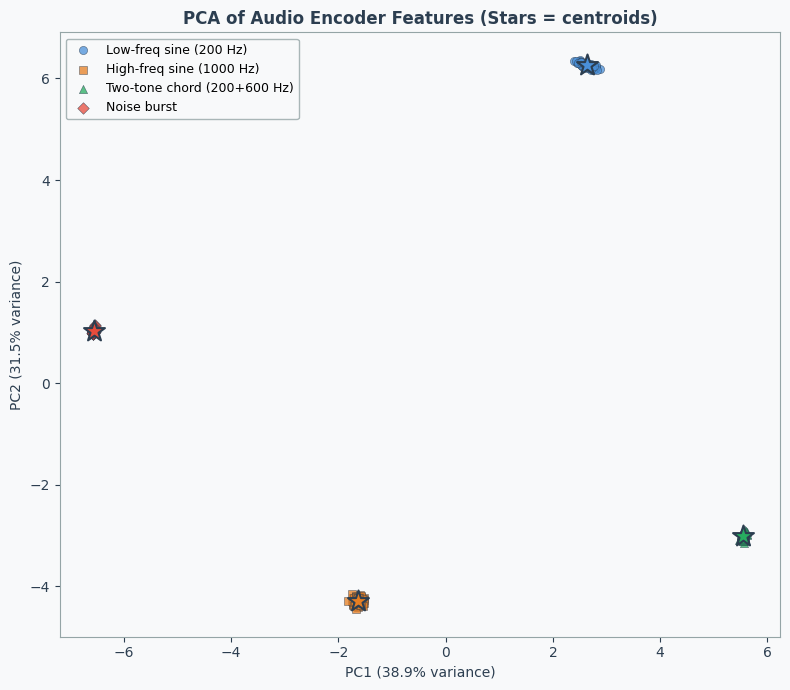

PCA captures 70.3% of total variance in first 2 components.
Clear cluster separation indicates the encoder learned discriminative features!


In [18]:
def show_feature_clustering(model, dataset, device=DEVICE, method='pca'):
    """
    Extract encoder features for all samples and visualise with PCA.
    Well-separated clusters show the encoder has learned discriminative representations.
    """
    from sklearn.decomposition import PCA

    model.eval()
    loader   = DataLoader(dataset, batch_size=128, shuffle=False)
    features = []
    labels   = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            enc = model.encode(x)           # (B, T', D)
            feat = enc.mean(dim=1).cpu().numpy()  # (B, D) — avg pool
            features.append(feat)
            y_arr = y if isinstance(y, np.ndarray) else np.array(y)
            labels.extend(y_arr.tolist())

    features = np.concatenate(features, axis=0)   # (N, D)
    labels   = np.array(labels)

    # PCA to 2D
    pca  = PCA(n_components=2, random_state=42)
    feat_2d = pca.fit_transform(features)

    fig, ax = plt.subplots(figsize=(8, 7), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    colors  = [PAL['blue'], PAL['orange'], PAL['green'], PAL['red']]
    markers = ['o', 's', '^', 'D']

    for cls in range(4):
        mask = labels == cls
        ax.scatter(feat_2d[mask, 0], feat_2d[mask, 1],
                   color=colors[cls], marker=markers[cls],
                   s=35, alpha=0.75, label=CLASS_NAMES[cls],
                   edgecolors=PAL['dark'], linewidths=0.4)

    # Cluster centroids
    for cls in range(4):
        mask = labels == cls
        cx, cy = feat_2d[mask, 0].mean(), feat_2d[mask, 1].mean()
        ax.scatter(cx, cy, color=colors[cls], marker='*',
                   s=250, edgecolors=PAL['dark'], linewidths=1.5, zorder=5)

    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', color=PAL['dark'])
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', color=PAL['dark'])
    ax.set_title('PCA of Audio Encoder Features (Stars = centroids)',
                 color=PAL['dark'], fontsize=12, fontweight='bold')
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'], fontsize=9)
    ax.tick_params(colors=PAL['dark'])
    for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])
    plt.tight_layout()
    plt.show()

    total_var = (var_exp[0] + var_exp[1]) * 100
    print(f"PCA captures {total_var:.1f}% of total variance in first 2 components.")
    print("Clear cluster separation indicates the encoder learned discriminative features!")

show_feature_clustering(model, mel_ds)

### The Cross-Attention Decoder (Whisper's Transcription Path)

In full Whisper, the **decoder** generates the transcript token-by-token.
Each decoder step:
1. Causal self-attention over previously generated tokens
2. **Cross-attention** to encoder output — the decoder "looks at" the audio
3. FFN → next token prediction

Below we show a minimal demo with random token sequences to confirm shapes.

In [19]:
class MiniWhisperDecoder(nn.Module):
    """
    Minimal Whisper-style decoder for demonstration.
    In a real system vocab_size ~ 50,000 (Whisper's BPE vocabulary).
    """
    def __init__(self, vocab_size=50, embed_dim=64, depth=2, n_heads=4,
                 max_seq_len=32):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        self.blocks    = nn.ModuleList([
            TransformerDecoderBlock(embed_dim, n_heads) for _ in range(depth)
        ])
        self.norm    = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)

    def forward(self, tokens, enc_out):
        B, T = tokens.shape
        pos  = torch.arange(T, device=tokens.device).unsqueeze(0)
        x    = self.embed(tokens) + self.pos_embed(pos)
        for blk in self.blocks:
            x = blk(x, enc_out)
        x = self.norm(x)
        return self.lm_head(x)   # (B, T, vocab_size)


# Demo: encode audio → decode to tokens
decoder  = MiniWhisperDecoder(vocab_size=50, embed_dim=64, depth=2, n_heads=4).to(DEVICE)
sample_mel_batch = mel_ds[0][0].unsqueeze(0).to(DEVICE)  # (1, 1, 40, T)

with torch.no_grad():
    enc_features = model.encode(sample_mel_batch)          # (1, T', 64)
    token_seq    = torch.zeros(1, 8, dtype=torch.long, device=DEVICE)  # start tokens
    logits       = decoder(token_seq, enc_features)         # (1, 8, vocab_size)

print("Cross-attention decoder demo:")
print(f"  Audio encoder output : {enc_features.shape}")
print(f"  Decoder token input  : {token_seq.shape}")
print(f"  Decoder logit output : {logits.shape}  (B, seq_len, vocab_size)")
print()
print("In real Whisper:")
print("  - enc_features shape: (B, 1500, 512)  [1500 = 3000//2 frames]")
print("  - vocab_size: 51,865  [BPE + special tokens]")
print("  - depth: 6 encoder + 6 decoder blocks (Whisper-base)")

Cross-attention decoder demo:
  Audio encoder output : torch.Size([1, 63, 64])
  Decoder token input  : torch.Size([1, 8])
  Decoder logit output : torch.Size([1, 8, 50])  (B, seq_len, vocab_size)

In real Whisper:
  - enc_features shape: (B, 1500, 512)  [1500 = 3000//2 frames]
  - vocab_size: 51,865  [BPE + special tokens]
  - depth: 6 encoder + 6 decoder blocks (Whisper-base)


## Exercises

1. **Mel resolution sweep** — Run three experiments with `n_mels` ∈ {16, 64, 128}. Plot classification accuracy vs mel bins. At what resolution does the mel spectrogram lose enough frequency detail to significantly hurt the classifier? Which audio classes are most sensitive to mel resolution?

2. **Raw waveform patches** — Instead of computing a mel spectrogram, divide the raw waveform into 1-D patches of length 256 using `nn.Conv1d(1, embed_dim, kernel_size=256, stride=256)`. Does a Transformer on raw audio patches learn as fast as one on mel patches? What does the first Conv1d layer learn to detect?

3. **Audio + image fusion (preview of Ch10)** — Take the trained `AudioEncoder` from this chapter and the `ViT` from Ch01. Concatenate their [CLS] token outputs and attach a 2-layer fusion classifier. Create a paired dataset where audio class matches image class (e.g., 200 Hz sine + red circle). Train the fusion model and compare its accuracy to either unimodal model alone.

## Scaling to Real Data

| Hyperparameter | This notebook | Whisper-medium | Whisper-large-v3 |
|---|---|---|---|
| `n_mels` | 64 | 80 | 128 |
| Audio context | ~1 s (synthetic) | 30 s | 30 s |
| Encoder layers | 4 | 24 | 32 |
| Encoder dim | 64 | 1 024 | 1 280 |
| Encoder heads | 4 | 16 | 20 |
| Parameters | ~0.1 M | 307 M | 1.54 B |
| Training data | 400 synthetic clips | 680 K hours | 5 M hours |
| Task | 4-class classification | Speech recognition (multilingual) | Speech recognition |

**Mel spectrogram standardisation:** Whisper uses 80 mel bins (large-v3 uses 128), a 25ms window, 10ms hop, and normalises the log-mel to zero mean / unit variance per clip. The triangular filterbank you built by hand here is exactly what `torchaudio.transforms.MelSpectrogram` computes.

**To use a real Whisper encoder:**
```python
import whisper
model = whisper.load_model("base")           # 74M params
audio = whisper.load_audio("speech.wav")
mel = whisper.log_mel_spectrogram(audio)     # (80, 3000) — 30s at 10ms hop
features = model.encoder(mel.unsqueeze(0))   # (1, 1500, 512) — patch tokens
# features[:,0] is the equivalent of the CLS token
```

## Chapter Summary

**What we built** — An audio understanding pipeline built entirely from scratch: a mel spectrogram computation (manual STFT → triangular filterbank → log compression, no torchaudio), a Whisper-style encoder with 1-D convolutional patch embedding, a 4-layer Transformer encoder, and a linear classification head. Trained on 4-class synthetic audio (200 Hz sine, 1 kHz sine, chord, noise burst), the model learns to distinguish audio categories from their spectral patterns.

**Why it matters** — The mel spectrogram is the "patch embedding" for audio: it converts a continuous 1-D signal into a 2-D time-frequency image that a Transformer can process identically to vision. This equivalence means every architectural idea in the book — bidirectional attention, [CLS] pooling, two-stage training — carries over to audio without modification.

**Connections** — The AudioEncoder here is a direct replacement for the ViT in Ch03's VLM: plug it into the ProjectionMLP → GPT pipeline and you have a speech-and-vision language model. Ch09 makes an analogous extension to video. Ch10 (Capstone) assembles all three encoders into a unified model that processes image + audio + text simultaneously.